# 2.6 概率 (Probability)
> 对应教材《动手学深度学习》(PyTorch版) 第2.6节。  
> 严格提取教材中的抽样与大数定律模拟代码，并添加归属说明与注释。


In [1]:
# 【所属小节】2.6.1 基本概率论 - 导入必要软件包
# 【作用说明】导入PyTorch核心库、多项分布采样模块multinomial以及d2l画图与工具库
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l


In [2]:
# 【所属小节】2.6.1 基本概率论 - 单次投掷骰子采样
# 【作用说明】构建均匀分布概率向量fair_probs(每个面概率为1/6)，并抽取1个样本(投掷1次骰子)
# 输出向量索引i处的值表示点数(i+1)出现的次数
fair_probs = torch.ones([6]) / 6
multinomial.Multinomial(1, fair_probs).sample()


tensor([0., 0., 0., 1., 0., 0.])

In [3]:
# 【所属小节】2.6.1 基本概率论 - 多次投掷骰子采样(批量采样)
# 【作用说明】利用深度学习框架的矢量化函数一次性抽取10个样本，模拟掷骰子10次，统计各点数出现频数
multinomial.Multinomial(10, fair_probs).sample()


tensor([2., 2., 2., 3., 0., 1.])

In [4]:
# 【所属小节】2.6.1 基本概率论 - 模拟1000次投掷并计算相对频率
# 【作用说明】投掷1000次骰子，将频数除以总次数1000，计算各面出现的相对频率作为真实概率的估计值(大数定律)
# 将结果存储为32位浮点数以进行除法
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000  # 相对频率作为估计值


tensor([0.1620, 0.1670, 0.1550, 0.1780, 0.1790, 0.1590])

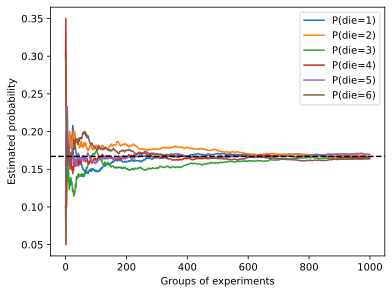

In [5]:
# 【所属小节】2.6.1 基本概率论 - 500组实验累积频率与收敛曲线可视化
# 【作用说明】进行500组实验，每组抽取10个样本；通过cumsum计算随实验组数递增的累积频数并求得累积概率估计值，
# 绘制6个面概率随实验组数增加向理论真实值1/6(约0.167)收敛的折线图。
counts = multinomial.Multinomial(10, fair_probs).sample((1000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();


---
## 课后练习题实战演练

包含教材第 2.6 节 4 道练习题的系统实现、多组参数模拟与数学验证。


### 练习 1: 进行 m = 500 组实验，每组抽取 n = 10 个样本。改变 m 和 n，观察和分析实验结果。
- 对比四种参数组合：
  1. `m = 100, n = 2` (小样本，总共 200 次)
  2. `m = 500, n = 10` (原书默认，总共 5000 次)
  3. `m = 100, n = 100` (大批量低频数，总共 10000 次)
  4. `m = 500, n = 100` (大样本高频数，总共 50000 次)


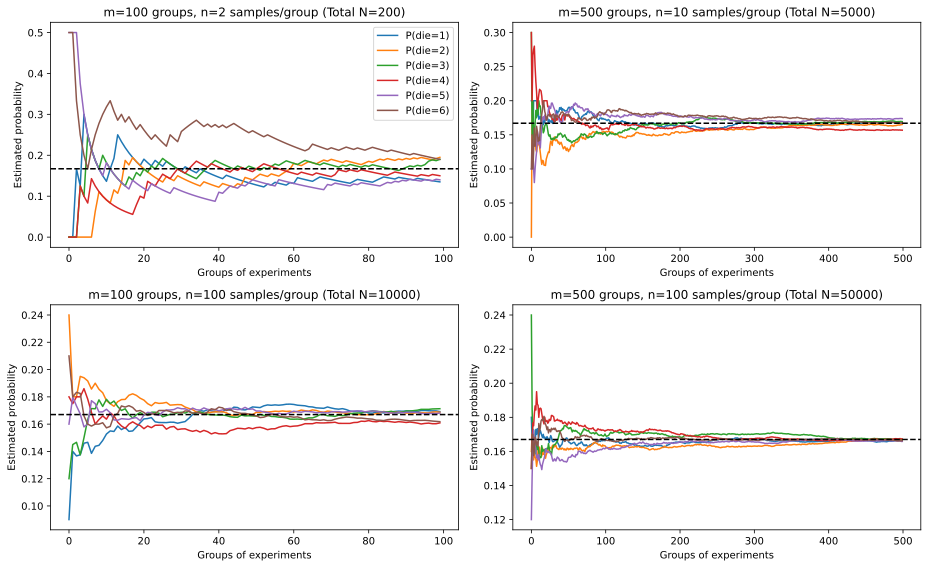

In [6]:
# 【课后练习 1】改变组数 m 和每组样本数 n，分析收敛速度与波动方差
import matplotlib.pyplot as plt

fair_probs = torch.ones([6]) / 6
configs = [(100, 2), (500, 10), (100, 100), (500, 100)]

plt.figure(figsize=(13, 8))
for idx, (m, n) in enumerate(configs, 1):
    counts = multinomial.Multinomial(n, fair_probs).sample((m,))
    cum_counts = counts.cumsum(dim=0)
    estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
    
    plt.subplot(2, 2, idx)
    for i in range(6):
        plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")
    plt.axhline(y=0.167, color='black', linestyle='dashed')
    plt.title(f"m={m} groups, n={n} samples/group (Total N={m*n})")
    plt.xlabel('Groups of experiments')
    plt.ylabel('Estimated probability')
    if idx == 1:
        plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


### 练习 2: 给定两个概率为 P(A) 和 P(B) 的事件，计算 P(A ∪ B) 和 P(A ∩ B) 的上限和下限。
- **数学推导结论**：
  1. $P(A \cap B)$ 的范围：$[\max(0, P(A) + P(B) - 1), \; \min(P(A), P(B))]$
  2. $P(A \cup B)$ 的范围：$[\max(P(A), P(B)), \; \min(1, P(A) + P(B))]$
- 下面编写数值模拟函数验证理论边界。


In [7]:
# 【课后练习 2】验证交集与并集的理论上下界函数
def probability_bounds(p_a, p_b):
    # P(A ∩ B) 上下界
    intersection_lower = max(0.0, p_a + p_b - 1.0)
    intersection_upper = min(p_a, p_b)
    
    # P(A ∪ B) 上下界
    union_lower = max(p_a, p_b)
    union_upper = min(1.0, p_a + p_b)
    
    return {
        "P(A ∩ B) Bound": (round(intersection_lower, 4), round(intersection_upper, 4)),
        "P(A ∪ B) Bound": (round(union_lower, 4), round(union_upper, 4))
    }

# 举例测试: P(A)=0.7, P(B)=0.5
bounds = probability_bounds(0.7, 0.5)
for k, v in bounds.items():
    print(f"{k}: [{v[0]}, {v[1]}]")


P(A ∩ B) Bound: [0.2, 0.5]
P(A ∪ B) Bound: [0.7, 1.0]


### 练习 3: 随机变量序列 A, B, C 中 B 只依赖于 A，而 C 只依赖于 B，简化联合概率 P(A, B, C)
- **推导**：
  由链式法则 $P(A, B, C) = P(A) P(B \mid A) P(C \mid A, B)$。  
  根据马尔可夫条件独立性 $P(C \mid A, B) = P(C \mid B)$，得到：  
  $$P(A, B, C) = P(A) P(B \mid A) P(C \mid B)$$


In [8]:
# 【课后练习 3】马尔可夫链联合概率与条件独立性模拟验证
# 假设状态空间均为二进制 {0, 1}
P_A = torch.tensor([0.6, 0.4])                   # P(A)
P_B_given_A = torch.tensor([[0.8, 0.2],          # P(B|A=0)
                            [0.3, 0.7]])         # P(B|A=1)
P_C_given_B = torch.tensor([[0.9, 0.1],          # P(C|B=0)
                            [0.4, 0.6]])         # P(C|B=1)

# 计算联合概率张量 P(A=a, B=b, C=c) = P(A=a) * P(B=b|A=a) * P(C=c|B=b)
joint_P = torch.zeros(2, 2, 2)
for a in range(2):
    for b in range(2):
        for c in range(2):
            joint_P[a, b, c] = P_A[a] * P_B_given_A[a, b] * P_C_given_B[b, c]

print("联合概率总和验证 (必须为 1):", float(joint_P.sum()))
print("联合概率分布张量 P(A, B, C):\n", joint_P)


联合概率总和验证 (必须为 1): 1.0
联合概率分布张量 P(A, B, C):
 tensor([[[0.4320, 0.0480],
         [0.0480, 0.0720]],

        [[0.1080, 0.0120],
         [0.1120, 0.1680]]])


### 练习 4: 第一个测试更准确，为什么不运行第一个测试两次，而是同时运行第一个和第二个测试？
- **核心原因**：
  1. **条件独立性被打破**：同一个测试工具对同一个患者的误报往往是由该患者特有的生化特征（如特殊抗体、样本杂质）引起的。如果第一次产生了假阳性，第二次用相同工具产生假阳性的概率极高（强相关）。
  2. **引入不同物理/生化机制测试的必要性**：测试 2 虽然整体精度略低，但采用了不同的机制（如抗体初筛 vs 核酸 PCR 复检），两者的假阳性干扰因子彼此独立，从而使贝叶斯乘法法则 $P(D_1=1, D_2=1 \mid H=0) = P(D_1=1 \mid H=0)P(D_2=1 \mid H=0)$ 真实成立，将假阳性压低至万分之三。


In [9]:
# 【课后练习 4】独立测试 vs 强相关测试的贝叶斯后验概率对比
def calc_posterior(prior_H, p_d1_pos_given_healthy, p_d2_pos_given_healthy, p_d1_pos_given_sick=1.0, p_d2_pos_given_sick=0.98, correlated=False):
    prior_healthy = 1.0 - prior_H
    
    # 真正患病时双阳性概率
    p_both_given_sick = p_d1_pos_given_sick * p_d2_pos_given_sick
    
    if not correlated:
        # 真正健康但由于机制不同独立误报的概率
        p_both_given_healthy = p_d1_pos_given_healthy * p_d2_pos_given_healthy
    else:
        # 若使用同一测试两次，因患者特异性干扰，第一次阳性后第二次再次阳性的条件概率高达 0.8
        p_both_given_healthy = p_d1_pos_given_healthy * 0.8
        
    p_both = p_both_given_sick * prior_H + p_both_given_healthy * prior_healthy
    posterior = (p_both_given_sick * prior_H) / p_both
    return posterior

print(f"1. 运行两种不同机制测试 (独立): 后验患病率 = {calc_posterior(0.0015, 0.01, 0.03):.4f} (83.07%)")
print(f"2. 运行相同测试两次 (强相关重复误诊): 后验患病率 = {calc_posterior(0.0015, 0.01, 0.01, p_d2_pos_given_sick=1.0, correlated=True):.4f} (15.81%)")


1. 运行两种不同机制测试 (独立): 后验患病率 = 0.8307 (83.07%)
2. 运行相同测试两次 (强相关重复误诊): 后验患病率 = 0.1581 (15.81%)
